In [1]:
%cd "F:\KIM\020_Project\260207.010_금융데이터"

[Errno 2] No such file or directory: 'F:\\KIM\\020_Project\\260207.010_금융데이터'
/app/notebook


In [2]:
import pandas as pd
from kis import kis_api
from datetime import datetime

In [3]:
def query_time_price(code, date, time):
    r = kis_api.domestic_stock_inquire_time_dailychartprice(code=code, date=date, time=time)
    df = pd.DataFrame(r['output2'])
    df ['code'] = code
    df.rename(columns={'stck_bsop_date': 'date','stck_cntg_hour': 'time', 'stck_prpr':'close','stck_oprc':'open','stck_hgpr':'high','stck_lwpr':'low','cntg_vol':'volume'}, inplace=True)
    df['datetime'] = pd.to_datetime(df['date'] + df['time'], format='%Y%m%d%H%M%S')
    cols = ['code', 'datetime', 'open', 'high', 'low', 'close', 'volume']
    df = df[cols]
    return df

In [4]:
query_time_price(code='001290', date='20260219', time='093000')

,code,datetime,open,high,low,close,volume
0,001290,2026-02-19 09:30:00,1175,1175,1175,1175,10770
1,001290,2026-02-19 09:29:00,1175,1175,1175,1175,4172
2,001290,2026-02-19 09:28:00,1175,1175,1175,1175,6231
3,001290,2026-02-19 09:27:00,1175,1175,1175,1175,14546
4,001290,2026-02-19 09:26:00,1175,1175,1175,1175,9389
5,001290,2026-02-19 09:25:00,1175,1175,1175,1175,8260
6,001290,2026-02-19 09:24:00,1175,1175,1175,1175,11480
7,001290,2026-02-19 09:23:00,1175,1175,1175,1175,8156
8,001290,2026-02-19 09:22:00,1175,1175,1175,1175,16034
9,001290,2026-02-19 09:21:00,1175,1175,1175,1175,71780


In [5]:
def query_minute_price_by_date(code: str, date: str, max_loops: int = 200) -> pd.DataFrame:

    def query_time_price(code, date, time):
        r = kis_api.domestic_stock_inquire_time_dailychartprice(code=code, date=date, time=time)
        if len(r['output2']) == 0:
            return pd.DataFrame()  # 빈 데이터프레임 반환
        df = pd.DataFrame(r['output2'])
        df ['code'] = code
        df.rename(columns={'stck_bsop_date': 'date','stck_cntg_hour': 'time', 'stck_prpr':'close','stck_oprc':'open','stck_hgpr':'high','stck_lwpr':'low','cntg_vol':'volume'}, inplace=True)
        df['datetime'] = pd.to_datetime(df['date'] + df['time'], format='%Y%m%d%H%M%S')
        cols = ['code', 'datetime', 'open', 'high', 'low', 'close', 'volume']
        df = df[cols]
        return df

    def dt_to_yyyymmdd_hhmmss(dt: pd.Timestamp) -> tuple[str, str]:
        # dt: pandas Timestamp
        return dt.strftime("%Y%m%d"), dt.strftime("%H%M%S")

    """
    - query_time_price(code, date, time)로 df를 가져옴
    - df의 마지막 datetime에서 1분 전을 다음 호출 파라미터로 삼아 반복
    - df의 '마지막 행' 시간이 09:00이 될 때까지(또는 09:00 이하로 내려갈 때까지) 반복
    - 결과는 하나로 concat하여 반환
    """
    chunks = []

    # 목표 시각(같은 날 09:00)
    target_dt = pd.to_datetime(date + "090000", format="%Y%m%d%H%M%S")

    cur_date, cur_time = date, '160000'
    for _ in range(max_loops):
        df = query_time_price(code, cur_date, cur_time)
        if df.empty:
            break

        # 안전: datetime 정렬
        # df = df.sort_values("datetime")
        chunks.append(df)

        last_dt = df.iloc[-1]["datetime"]  # 마지막 행 datetime

        # 종료 조건: 마지막 행이 09:00 이하(=09:00 도달)면 끝
        if last_dt <= target_dt and last_dt.strftime("%H%M%S") == "090000":
            break
        if last_dt < target_dt:
            # 09:00을 이미 지나쳐(더 과거로) 내려가 버렸다면 종료
            break

        # 다음 호출 시각: 마지막 행의 1분 전
        next_dt = last_dt - pd.Timedelta(minutes=1)
        cur_date, cur_time = dt_to_yyyymmdd_hhmmss(next_dt)

        # 같은 날짜 09:00보다 더 내려가면 호출 의미가 없으니 중단
        if next_dt < target_dt:
            break
    if not chunks:
        return pd.DataFrame()  # 데이터가 하나도 없는 경우 빈 데이터프레임 반환
    # 합치기 + 중복 제거 + 정렬
    out = pd.concat(chunks, ignore_index=True)

    out = out.drop_duplicates(subset=["code", "datetime"], keep="last")
    out = out.sort_values(["code", "datetime"]).reset_index(drop=True)

    # # 09:00~원래 요청 time까지로 잘라서 반환(원하면 제거 가능)
    # end_dt = pd.to_datetime(date + time, format="%Y%m%d%H%M%S")
    # out = out[(out["datetime"] >= target_dt) & (out["datetime"] <= end_dt)].reset_index(drop=True)

    return out

In [6]:
query_minute_price_by_date(code='001510', date='20260219')

/tmp/ipykernel_3055/164260949.py:50: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  next_dt = last_dt - pd.Timedelta(minutes=1)
/tmp/ipykernel_3055/164260949.py:50: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  next_dt = last_dt - pd.Timedelta(minutes=1)
/tmp/ipykernel_3055/164260949.py:50: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  next_dt = last_dt - pd.Timedelta(minutes=1)
/tmp/ipykernel_3055/164260949.py:50: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, a

,code,datetime,open,high,low,close,volume
0,001510,2026-02-19 09:02:00,2899,3081,2873,3007,10954358
1,001510,2026-02-19 09:03:00,3011,3107,3003,3057,4525729
2,001510,2026-02-19 09:04:00,3053,3103,3011,3097,3067696
3,001510,2026-02-19 09:05:00,3095,3143,3079,3141,3286013
4,001510,2026-02-19 09:06:00,3143,3161,3139,3161,3820874
...,...,...,...,...,...,...,...
374,001510,2026-02-19 15:16:00,3161,3161,3161,3161,357
375,001510,2026-02-19 15:17:00,3161,3161,3161,3161,334
376,001510,2026-02-19 15:18:00,3161,3161,3161,3161,14684
377,001510,2026-02-19 15:19:00,3161,3161,3161,3161,92


In [7]:
from pykrx import stock
import pandas as pd

start = '20250301'
end = datetime.now().strftime("%Y%m%d")
print(end)
days = stock.get_previous_business_days(fromdate=start, todate="20260301")
print(days)

KRX 로그인 실패: KRX_ID 또는 KRX_PW 환경 변수가 설정되지 않았습니다.
20260719
Error occurred in get_market_ohlcv_by_date: Expecting value: line 1 column 1 (char 0)
[]


In [8]:
def get_top_by_date(date, threshold=29):
    df = stock.get_market_ohlcv_by_ticker(date, market="KOSPI")
    return df[df['등락률'] > threshold].nlargest(5, '등락률').index.tolist()

In [19]:
stock.get_market_ohlcv_by_ticker("20260714")

KeyError: "None of [Index(['시가', '고가', '저가', '종가'], dtype='object')] are in the [columns]"

In [22]:
get_top_by_date(datetime.now().timestamp())

AttributeError: 'float' object has no attribute 'replace'

In [11]:
def get_open_data_for_pre_date_top_stocks(date, interval='090500', threshold=29):
    
    top_stocks = get_top_by_date(date, threshold)
    if not top_stocks:
        return pd.DataFrame()  # 조건에 맞는 주식이 하나도 없는 경우 빈 데이터프레임 반환
    timelimit = pd.to_datetime(date.strftime("%Y%m%d") + interval, format="%Y%m%d%H%M%S")
    dfs = []
    for stock in top_stocks:
        # print(stock)
        # print(date.strftime("%Y%m%d"))
        df = query_minute_price_by_date(code=stock, date=date.strftime("%Y%m%d"))
        # print(df)
        if df.empty:
            continue
        df = df[df['datetime'] <= timelimit]
        dfs.append(df)
    if not dfs:
        return pd.DataFrame()  # 데이터가 하나도 없는 경우 빈 데이터프레임 반환
    return pd.concat(dfs, ignore_index=True)

In [13]:
dfs = []
for date in days[:10]:
    df = get_open_data_for_pre_date_top_stocks(date=date)
    if not df.empty:
        dfs.append(df)
top_df = pd.concat(dfs, ignore_index=True)

KeyboardInterrupt: 

In [15]:
top_df

,code,datetime,open,high,low,close,volume
0,097230,2025-03-04 09:00:00,6290,6300,6220,6250,14073
1,097230,2025-03-04 09:01:00,6250,6280,6190,6210,5038
2,097230,2025-03-04 09:02:00,6220,6250,6210,6240,4942
3,097230,2025-03-04 09:03:00,6240,6270,6240,6260,5773
4,097230,2025-03-04 09:04:00,6260,6380,6260,6360,17743
...,...,...,...,...,...,...,...
681,001270,2025-07-09 09:04:00,52800,53400,52500,53300,6626
682,001270,2025-07-09 09:05:00,53400,53500,52300,52400,7439
683,015260,2025-07-10 09:00:00,446,464,436,437,51599
684,015260,2025-07-10 09:03:00,438,481,438,481,200554


In [16]:
cols = ['open', 'high', 'low', 'close', 'volume']

top_df[cols] = top_df[cols].apply(pd.to_numeric)

top_df['date'] = top_df['datetime'].dt.date
open_0900 = (
    top_df[top_df['datetime'].dt.strftime('%H:%M:%S') == '09:00:00']
    .set_index(['code', 'date'])['open']
)
top_df['open_0900'] = top_df.set_index(['code', 'date']).index.map(open_0900)
top_df['high_ratio'] = top_df['high'] / top_df['open_0900']
top_df['time_str'] = top_df['datetime'].dt.strftime('%H:%M')
top_df['symbol_day'] = top_df['code'] + "_" + top_df['date'].astype(str)
top_df

,code,datetime,open,high,low,close,volume,date,open_0900,high_ratio,time_str,symbol_day
0,097230,2025-03-04 09:00:00,6290,6300,6220,6250,14073,2025-03-04,6290.0,1.001590,09:00,097230_2025-03-04
1,097230,2025-03-04 09:01:00,6250,6280,6190,6210,5038,2025-03-04,6290.0,0.998410,09:01,097230_2025-03-04
2,097230,2025-03-04 09:02:00,6220,6250,6210,6240,4942,2025-03-04,6290.0,0.993641,09:02,097230_2025-03-04
3,097230,2025-03-04 09:03:00,6240,6270,6240,6260,5773,2025-03-04,6290.0,0.996820,09:03,097230_2025-03-04
4,097230,2025-03-04 09:04:00,6260,6380,6260,6360,17743,2025-03-04,6290.0,1.014308,09:04,097230_2025-03-04
...,...,...,...,...,...,...,...,...,...,...,...,...
681,001270,2025-07-09 09:04:00,52800,53400,52500,53300,6626,2025-07-09,49800.0,1.072289,09:04,001270_2025-07-09
682,001270,2025-07-09 09:05:00,53400,53500,52300,52400,7439,2025-07-09,49800.0,1.074297,09:05,001270_2025-07-09
683,015260,2025-07-10 09:00:00,446,464,436,437,51599,2025-07-10,446.0,1.040359,09:00,015260_2025-07-10
684,015260,2025-07-10 09:03:00,438,481,438,481,200554,2025-07-10,446.0,1.078475,09:03,015260_2025-07-10


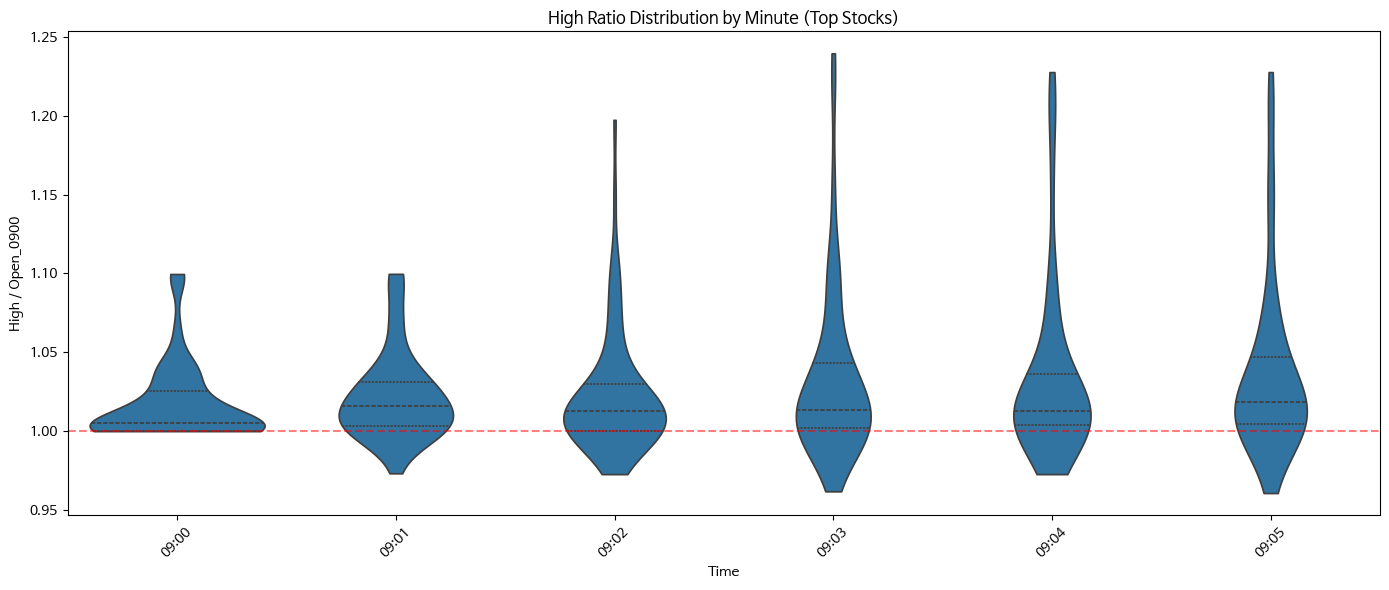

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.violinplot(
    data=top_df,
    x='time_str',
    y='high_ratio',
    inner='quartile',   # 중앙값 + 사분위
    cut=0               # 분포 튀어나오는 거 방지
)

plt.axhline(1.0, color='red', linestyle='--', alpha=0.5)  # 09:00 기준선

plt.title('High Ratio Distribution by Minute (Top Stocks)')
plt.xlabel('Time')
plt.ylabel('High / Open_0900')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

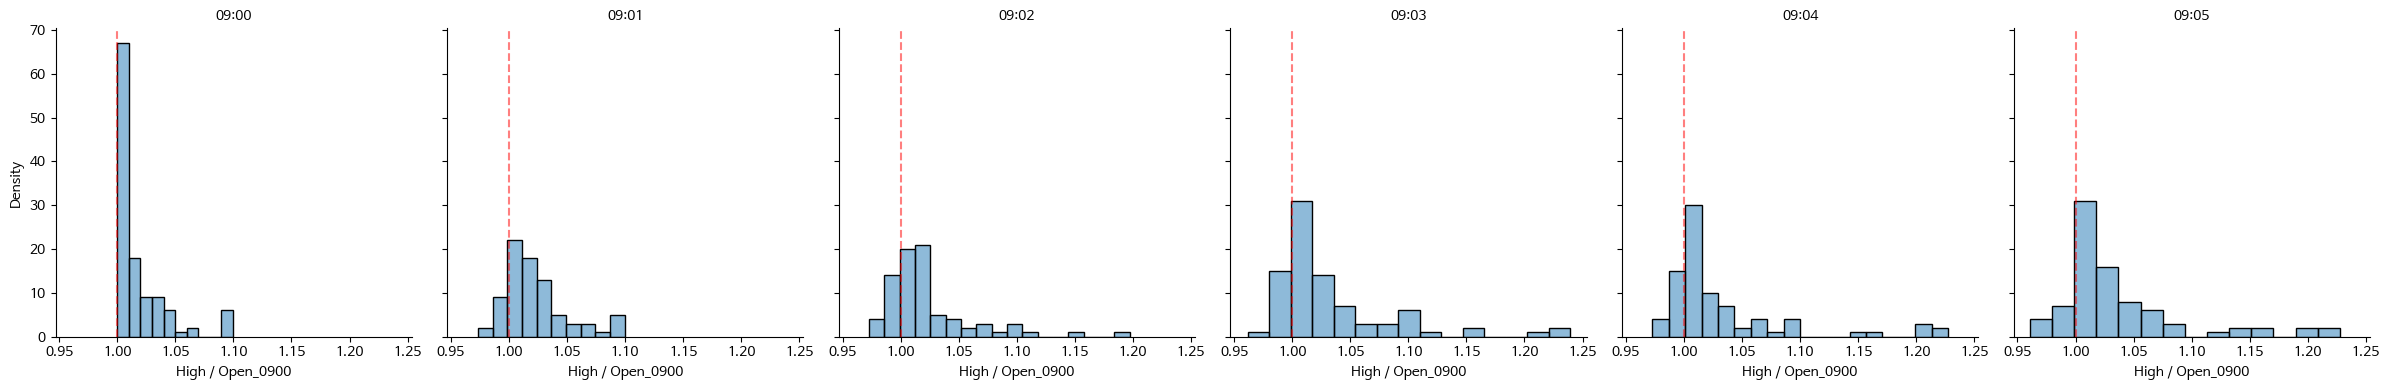

In [18]:
top_df['time_str'] = top_df['datetime'].dt.strftime('%H:%M')

g = sns.FacetGrid(
    top_df,
    col='time_str',
    col_wrap=6,        # 한 줄에 4개씩
    sharex=True,
    sharey=True,
    height=4
)

g.map_dataframe(
    sns.histplot,
    x='high_ratio',
    fill=True,
    alpha=0.5
)

for ax in g.axes.flat:
    ax.axvline(1.0, color='red', linestyle='--', alpha=0.5)

g.set_titles("{col_name}")
g.set_axis_labels("High / Open_0900", "Density")

plt.tight_layout()
plt.show()

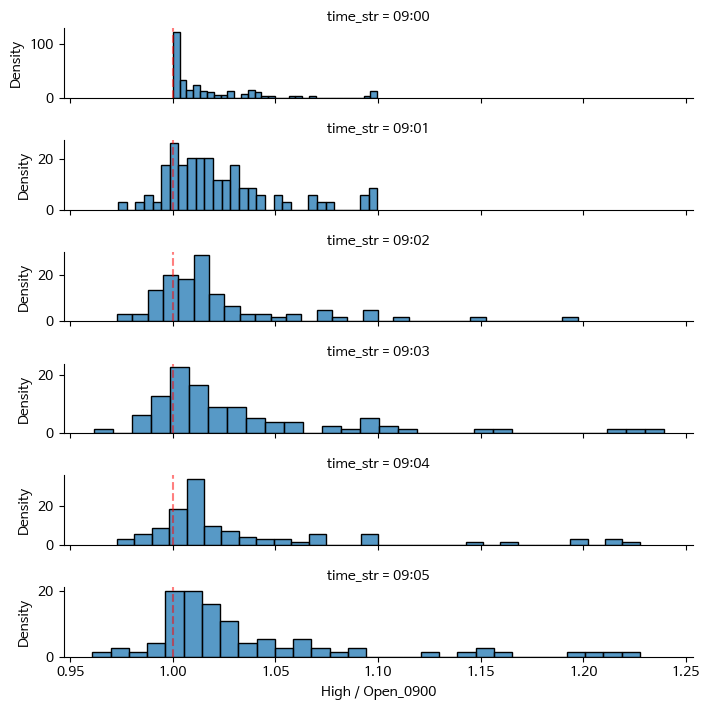

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    top_df,
    row='time_str',      # 한 줄에 하나씩
    sharex=True,
    sharey=False,
    height=1.2,
    aspect=6             # 가로로 길게
)

g.map_dataframe(
    sns.histplot,
    x='high_ratio',
    bins=30,
    stat='density'
)

for ax in g.axes.flat:
    ax.axvline(1.0, color='red', linestyle='--', alpha=0.5)

g.set_axis_labels("High / Open_0900", "Density")
plt.tight_layout()
plt.show()

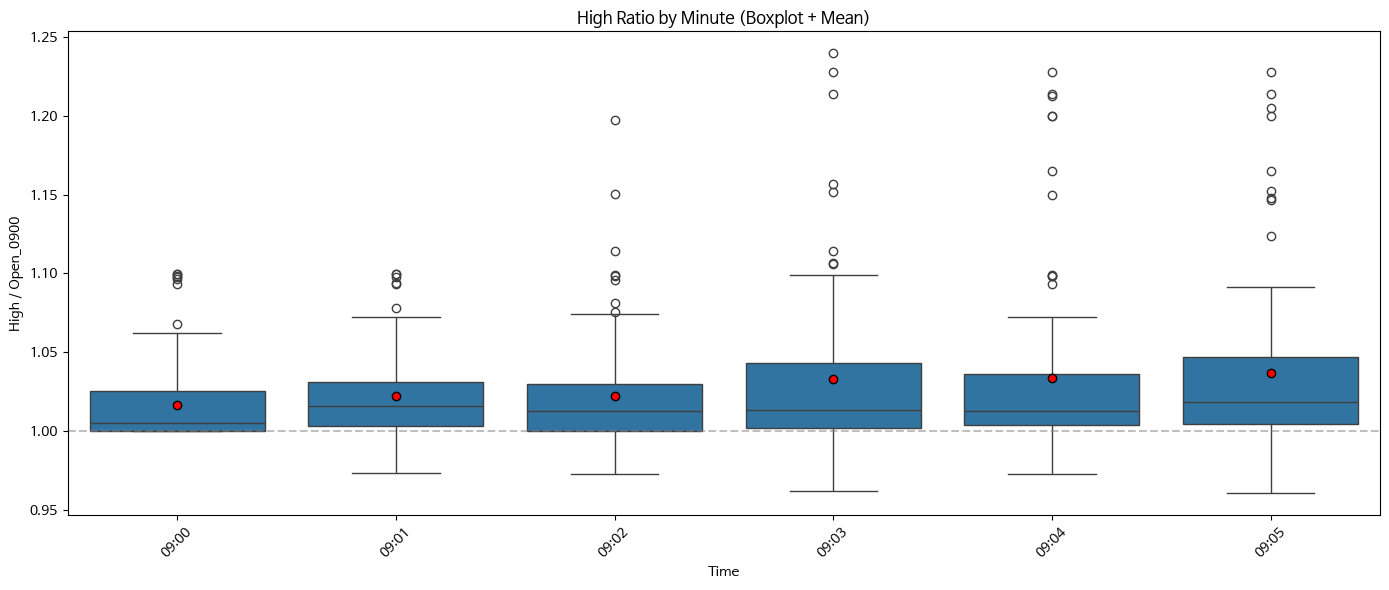

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

top_df['time_str'] = top_df['datetime'].dt.strftime('%H:%M')

plt.figure(figsize=(14,6))

sns.boxplot(
    data=top_df,
    x='time_str',
    y='high_ratio',
    showmeans=True,                      # 평균 표시
    meanprops={
        "marker":"o",
        "markerfacecolor":"red",
        "markeredgecolor":"black",
        "markersize":"6"
    }
)

plt.axhline(1.0, color='gray', linestyle='--', alpha=0.5)  # 09:00 기준선
plt.xlabel('Time')
plt.ylabel('High / Open_0900')
plt.title('High Ratio by Minute (Boxplot + Mean)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
top_df.groupby('time_str')['high_ratio'].mean()

time_str
09:00    1.016626
09:01    1.022351
09:02    1.022523
09:03    1.033081
09:04    1.033575
09:05    1.036809
Name: high_ratio, dtype: float64

In [22]:
count_top_df =top_df.groupby("symbol_day")['code'].count().sort_values(ascending=False)
count_top_df[count_top_df > 5]

symbol_day
012170_2025-04-01    6
013580_2025-04-08    6
024720_2025-06-18    6
024720_2025-03-17    6
020760_2025-06-27    6
015020_2025-04-01    6
015020_2025-03-26    6
014710_2025-04-08    6
014160_2025-04-08    6
013580_2025-04-18    6
013360_2025-04-01    6
051630_2025-04-08    6
013360_2025-03-26    6
000230_2025-07-07    6
012170_2025-03-11    6
011090_2025-04-02    6
011000_2025-05-22    6
010770_2025-04-03    6
008970_2025-06-30    6
008970_2025-03-18    6
051630_2025-04-04    6
071090_2025-03-05    6
008600_2025-04-04    6
194370_2025-05-27    6
487570_2025-05-29    6
483650_2025-05-22    6
377300_2025-06-20    6
377300_2025-06-09    6
322000_2025-05-14    6
286940_2025-06-16    6
271980_2025-03-18    6
249420_2025-07-07    6
152550_2025-06-13    6
075580_2025-05-21    6
123690_2025-06-20    6
109070_2025-04-16    6
101140_2025-04-28    6
097230_2025-03-04    6
093240_2025-04-01    6
093240_2025-03-26    6
090080_2025-04-14    6
083420_2025-04-10    6
008970_2025-03-05    6


In [ ]:
import backtrader as bt
import math

class OvernightMomentumStrategy(bt.Strategy):
    params = dict(
        buy_minutes="09:00",
        sell_minutes="09:03",
        cash_buffer=0.001,   # 0.1% 현금 남겨 주문 거절(Margin) 방지
    )

    def __init__(self):
        self.target_codes = [d._name for d in self.datas]
        self.ordered  = {d._name: False for d in self.datas}
        self.data_map = {d._name: d for d in self.datas}
        self.entry_dt = {d._name: None for d in self.datas}

    def update_stdata(self):
        pass

    def notify_order(self, order):
        print(f"Order Notification: {order.Status[order.status]} for {order.data._name} at {self.data.datetime.datetime()}")

    def _calc_all_in_size(self, d):
        """현재 가용현금으로 살 수 있는 최대 수량 계산"""
        cash = self.broker.getcash()

        # 시장가 근사 가격: close(또는 open으로 바꿔도 됨)
        px = float(d.close[0])

        if px <= 0:
            return 0

        # 수수료 고려 (설정 안 했으면 commission=0)
        comminfo = self.broker.getcommissioninfo(d)
        cost_per_share = px * (1.0 + comminfo.p.commission)

        usable_cash = cash * (1.0 - self.p.cash_buffer)
        size = int(math.floor(usable_cash / cost_per_share))
        return max(size, 0)
    
    def get_current_datetime(self, d):
        """데이터 d의 현재 바의 datetime을 반환하는 헬퍼 함수"""
        return d.datetime.datetime()
    
    def get_position_size(self, d):
        """데이터 d의 현재 포지션 수량을 반환하는 헬퍼 함수"""
        return self.getposition(d).size
    
    def st_buy(self, d, size):
        """d 종목을 size 수량만큼 매수하는 헬퍼 함수"""
        self.buy(data=d, size=size)

    def st_sell(self, d, size):
        """d 종목을 size 수량만큼 매도하는 헬퍼 함수"""
        self.sell(data=d, size=size)

    def next(self):
        for d in self.target_codes:
            dt = self.get_current_datetime(self.data_map[d])
            hhmm = dt.strftime("%H:%M")
            pos = self.get_position_size(self.data_map[d])
            
            if dt.strftime("%H:%M") >= self.params.buy_minutes and not self.ordered[d]:
                size = self._calc_all_in_size(self.data_map[d])
                if size > 0:
                    self.ordered[d] = True
                    self.entry_dt[d] = dt
                    self.st_buy(self.data_map[d], size)
                    print(f"buy {d} dt={dt} size={size}")
                else:
                    print(f"SKIP {d}")
            if self.entry_dt[d] is not None and pos > 0 and (self.ordered[d]) and hhmm >= self.params.sell_minutes:
                self.ordered[d] = False
                self.st_sell(self.data_map[d], pos)
                print(f"SELL {d} dt={dt} size={pos}")

In [44]:
import pandas as pd
import backtrader as bt

start_cash = 1_000_000
cash = start_cash

rows = []        # 종목별 결과
daily_rows = []  # 날짜별 합산 결과

# top_df는 최소한: ['date','code','datetime','open','high','low','close','volume'] 있어야 함

# 날짜 기준으로 "그 날짜에 존재하는 종목 수 N"을 계산하기 위해 date로 그룹
for date, df_day in top_df.groupby('date'):
    df_day = df_day.sort_values('datetime').copy()
    df_day['datetime'] = df_day['datetime'].dt.tz_localize(None)

    # 종목별 데이터 준비 (최소 2개 bar 이상만)
    per_code = {}
    for code, dfi in df_day.groupby('code'):
        dfi = dfi.sort_values('datetime').copy()
        dfi = dfi.set_index('datetime')
        if len(dfi) >= 2:
            per_code[code] = dfi

    codes = sorted(per_code.keys())
    n = len(codes)
    if n == 0:
        continue

    # ★ 같은 날짜에 종목이 여러개면 N분의 1만 넣는다
    alloc_cash = cash / n

    # 날짜 시작값/종료값(합산)
    day_start_cash = cash
    day_final_sum = 0.0
    day_closed_sum = 0
    day_won_sum = 0
    day_lost_sum = 0

    for code in codes:
        df = per_code[code]

        cerebro = bt.Cerebro(stdstats=False)
        data = bt.feeds.PandasData(
            dataname=df,
            timeframe=bt.TimeFrame.Minutes,
            compression=1
        )
        cerebro.adddata(data, name=str(code))

        # 각 종목 run은 alloc_cash로 시작
        cerebro.broker.setcash(alloc_cash)
        cerebro.broker.set_coo(True)  # open 체결 쓰면 켜두는게 편함(원치 않으면 False)

        # 전략 파라미터는 네 전략 시그니처에 맞춰서
        # hold_minutes="09:03" 같은 형식이면 그대로
        cerebro.addstrategy(OvernightMomentumStrategy)

        cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='ta')

        results = cerebro.run()
        if not results:
            # run 실패/전략 미실행 같은 케이스 방어
            final = alloc_cash
            ta = {}
        else:
            strat = results[0]
            final = cerebro.broker.getvalue()
            ta = strat.analyzers.ta.get_analysis()

        pnl = final - alloc_cash
        ret_pct = (final / alloc_cash - 1) * 100 if alloc_cash != 0 else 0.0

        closed = ta.get('total', {}).get('closed', 0)
        won = ta.get('won', {}).get('total', 0)
        lost = ta.get('lost', {}).get('total', 0)

        rows.append({
            "date": pd.to_datetime(date),
            "code": str(code),
            "n_in_date": n,
            "start_cash_alloc": alloc_cash,
            "final_value": final,
            "pnl": pnl,
            "ret_pct": ret_pct,
            "closed_trades": closed,
            "won": won,
            "lost": lost,
        })

        day_final_sum += final
        day_closed_sum += closed
        day_won_sum += won
        day_lost_sum += lost

    # 날짜 끝나면 cash를 "합산 최종가치"로 갱신 (누적 수익 반영)
    cash = day_final_sum

    daily_rows.append({
        "date": pd.to_datetime(date),
        "n_symbols": n,
        "day_start_cash": day_start_cash,
        "day_final_cash": cash,
        "day_pnl": cash - day_start_cash,
        "day_ret_pct": (cash / day_start_cash - 1) * 100 if day_start_cash != 0 else 0.0,
        "closed_trades": day_closed_sum,
        "won": day_won_sum,
        "lost": day_lost_sum,
    })

# 결과 모아서 보기
symbol_results_df = pd.DataFrame(rows).sort_values(["date", "code"])
daily_results_df = pd.DataFrame(daily_rows).sort_values("date")

print("\n=== 종목별 결과 (최근 30개) ===")
print(symbol_results_df.tail(30).to_string(index=False))

print("\n=== 날짜별 합산 결과 (최근 30개) ===")
print(daily_results_df.tail(30).to_string(index=False))

print("\n=== 전체 요약 ===")
print(f"Start Cash : {start_cash:,.0f}")
print(f"End Cash   : {cash:,.0f}")
print(f"Total PnL  : {cash - start_cash:,.0f}")
print(f"Return (%) : {(cash / start_cash - 1) * 100:.8f}%")


buy 097230 dt=2025-03-04 09:00:00 size=159
Order Notification: Submitted for 097230 at 2025-03-04 09:01:00
Order Notification: Accepted for 097230 at 2025-03-04 09:01:00
Order Notification: Completed for 097230 at 2025-03-04 09:01:00
buy 008970 dt=2025-03-05 09:00:00 size=397
Order Notification: Submitted for 008970 at 2025-03-05 09:01:00
Order Notification: Margin for 008970 at 2025-03-05 09:01:00
buy 071090 dt=2025-03-05 09:00:00 size=165
Order Notification: Submitted for 071090 at 2025-03-05 09:01:00
Order Notification: Accepted for 071090 at 2025-03-05 09:01:00
Order Notification: Completed for 071090 at 2025-03-05 09:01:00
buy 012170 dt=2025-03-11 09:00:00 size=661
Order Notification: Submitted for 012170 at 2025-03-11 09:01:00
Order Notification: Margin for 012170 at 2025-03-11 09:01:00
buy 009310 dt=2025-03-12 09:00:00 size=416
Order Notification: Submitted for 009310 at 2025-03-12 09:01:00
Order Notification: Accepted for 009310 at 2025-03-12 09:01:00
Order Notification: Comple

In [45]:
daily_results_df.head(40)

,date,n_symbols,day_start_cash,day_final_cash,day_pnl,day_ret_pct,closed_trades,won,lost
0,2025-03-04,1,1000000.0,1027030.0,27030.0,2.703000,0,0,0
1,2025-03-05,2,1027030.0,1028680.0,1650.0,0.160657,0,0,0
2,2025-03-11,1,1028680.0,1028680.0,0.0,0.000000,0,0,0
3,2025-03-12,2,1028680.0,1208279.0,179599.0,17.459171,0,0,0
4,2025-03-14,1,1208279.0,1240247.0,31968.0,2.645747,0,0,0
5,2025-03-17,1,1240247.0,1238527.0,-1720.0,-0.138682,0,0,0
6,2025-03-18,3,1238527.0,1247059.0,8532.0,0.688883,0,0,0
7,2025-03-20,1,1247059.0,1209859.0,-37200.0,-2.983018,0,0,0
8,2025-03-24,1,1209859.0,1206999.0,-2860.0,-0.236391,0,0,0
9,2025-03-26,4,1206999.0,1218833.0,11834.0,0.980448,0,0,0
